# Preprocessing QC summary


In [2]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
import matplotlib.pyplot as plt

# --- set your file path here ---
csv_path = "/cluster/project/reddy/katja/NGS_pipeline/data/P3408_LUCA-TCRA3/processed/27_01_2026_minLenght191_QScore20/bbduk_summary_20260127_11-27-18.csv"   # <-- change

df = pd.read_csv(csv_path)
df.head()


,sample_id,sample_name,sample_label,input_fastq,output_fastq,output_size_bytes,bbduk_version,reads_in,bases_in,reads_out,bases_out,reads_removed,bases_removed,reads_qtrimmed,bases_qtrimmed,runtime_s
0,GFB-61811,clibMAGE-A32xnegative,GFB-61811_clibMAGE-A32xnegative,/cluster/project/reddy/marluca/NGS_pipeline/da...,/cluster/project/reddy/katja/NGS_pipeline/data...,2205193739,39.33,31276031,6255206200,16036183,3187843710,15239848,3067362490,18752741,3067362490,129.126204
1,GFB-61811,clibMAGE-A32xnegative,GFB-61811_clibMAGE-A32xnegative,/cluster/project/reddy/marluca/NGS_pipeline/da...,/cluster/project/reddy/katja/NGS_pipeline/data...,1088809457,39.33,16957339,3391467800,8280714,1647546431,8676625,1743921369,10332736,1743921369,69.264287
2,GFB-61811,clibMAGE-A32xnegative,GFB-61811_clibMAGE-A32xnegative,/cluster/project/reddy/marluca/NGS_pipeline/da...,/cluster/project/reddy/katja/NGS_pipeline/data...,2746797039,39.33,41011350,8202270000,21026110,4183515894,19985240,4018754106,24192611,4018754106,175.054564
3,GFB-61811,clibMAGE-A32xnegative,GFB-61811_clibMAGE-A32xnegative,/cluster/project/reddy/marluca/NGS_pipeline/da...,/cluster/project/reddy/katja/NGS_pipeline/data...,1245040371,39.33,20811611,4162322200,9899658,1970848824,10911953,2191473376,12735076,2191473376,84.985605
4,GFB-61812,clibTitin2xnegative,GFB-61812_clibTitin2xnegative,/cluster/project/reddy/marluca/NGS_pipeline/da...,/cluster/project/reddy/katja/NGS_pipeline/data...,1651577396,39.33,20788874,4157774800,11915779,2368835718,8873095,1788939082,11459085,1788939082,91.419154


In [3]:
# Ensure numeric cols are numeric (in case they were read as strings)
num_cols = [
    "output_size_bytes",
    "reads_in","bases_in","reads_out","bases_out",
    "reads_removed","bases_removed",
    "reads_qtrimmed","bases_qtrimmed",
    "runtime_s"
]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Derive run_id from the input_fastq path: ".../run1-1000M/..." -> "run1-1000M"
def extract_run_id(p):
    if pd.isna(p):
        return np.nan
    m = re.search(r"/(run\d+-[^/]+)/", str(p))
    return m.group(1) if m else np.nan

df["run_id"] = df["input_fastq"].apply(extract_run_id)

# Optional: lane from filename "..._L001_..." -> "L001"
def extract_lane(p):
    if pd.isna(p):
        return np.nan
    m = re.search(r"_L(\d{3})_", str(p))
    return f"L{m.group(1)}" if m else np.nan

df["lane"] = df["input_fastq"].apply(extract_lane)

# Helpful QC metrics (guard against division by zero)
df["retention_reads_pct"] = 100 * df["reads_out"] / df["reads_in"]
df["retention_bases_pct"] = 100 * df["bases_out"] / df["bases_in"]
df["avg_read_len_in"] = df["bases_in"] / df["reads_in"]
df["avg_read_len_out"] = df["bases_out"] / df["reads_out"]
df["throughput_reads_per_s"] = df["reads_in"] / df["runtime_s"]
df["qtrim_share_of_removed_reads_pct"] = 100 * df["reads_qtrimmed"] / df["reads_removed"].replace(0, np.nan)

df[["sample_id","sample_name","run_id","lane","reads_in","reads_out","retention_reads_pct","runtime_s"]].head()


,sample_id,sample_name,run_id,lane,reads_in,reads_out,retention_reads_pct,runtime_s
0,GFB-61811,clibMAGE-A32xnegative,run1-1000M,L001,31276031,16036183,51.273076,129.126204
1,GFB-61811,clibMAGE-A32xnegative,run2-500M,L001,16957339,8280714,48.832626,69.264287
2,GFB-61811,clibMAGE-A32xnegative,run1-1000M,L002,41011350,21026110,51.269002,175.054564
3,GFB-61811,clibMAGE-A32xnegative,run2-500M,L002,20811611,9899658,47.567956,84.985605
4,GFB-61812,clibTitin2xnegative,run1-1000M,L001,20788874,11915779,57.318059,91.419154


In [4]:
group_cols = ["sample_id", "sample_name", "sample_label"]

sample_summary = (
    df.groupby(group_cols, dropna=False)
      .agg(
          n_rows=("input_fastq","count"),
          n_runs=("run_id", pd.Series.nunique),
          n_lanes=("lane", pd.Series.nunique),
          reads_in=("reads_in","sum"),
          reads_out=("reads_out","sum"),
          reads_removed=("reads_removed","sum"),
          reads_qtrimmed=("reads_qtrimmed","sum"),
          bases_in=("bases_in","sum"),
          bases_out=("bases_out","sum"),
          bases_removed=("bases_removed","sum"),
          bases_qtrimmed=("bases_qtrimmed","sum"),
          output_size_bytes=("output_size_bytes","sum"),
          runtime_s=("runtime_s","sum"),
      )
      .reset_index()
)

# Derived metrics on the aggregates
sample_summary["retention_reads_pct"] = 100 * sample_summary["reads_out"] / sample_summary["reads_in"]
sample_summary["retention_bases_pct"] = 100 * sample_summary["bases_out"] / sample_summary["bases_in"]
sample_summary["avg_read_len_in"] = sample_summary["bases_in"] / sample_summary["reads_in"]
sample_summary["avg_read_len_out"] = sample_summary["bases_out"] / sample_summary["reads_out"]
sample_summary["throughput_reads_per_s"] = sample_summary["reads_in"] / sample_summary["runtime_s"]

sample_summary.sort_values("reads_in", ascending=False).head(10)


,sample_id,sample_name,sample_label,n_rows,n_runs,n_lanes,reads_in,reads_out,reads_removed,reads_qtrimmed,...,bases_out,bases_removed,bases_qtrimmed,output_size_bytes,runtime_s,retention_reads_pct,retention_bases_pct,avg_read_len_in,avg_read_len_out,throughput_reads_per_s
8,GFB-61819,clibKH1672xnegative,GFB-61819_clibKH1672xnegative,4,2,2,142717391,94216882,48500509,64416074,...,18760808876,9782669324,9782669324,12064674177,677.341063,66.016399,65.727129,200.0,199.123644,210702.404875
7,GFB-61818,clibKH1652xnegative,GFB-61818_clibKH1652xnegative,4,2,2,128649198,71888520,56760678,69733041,...,14309812687,11420026913,11420026913,9223791691,565.274087,55.879493,55.615631,200.0,199.055603,227587.290592
29,GFB-61840,cliboriginallib,GFB-61840_cliboriginallib,4,2,2,113052526,63395513,49657013,60715753,...,12621164983,9989340217,9989340217,8323104995,492.252303,56.076158,55.819916,200.0,199.086093,229663.782967
3,GFB-61814,clibKH1592xnegative,GFB-61814_clibKH1592xnegative,4,2,2,112056719,64032197,48024522,59723149,...,12745634385,9665709415,9665709415,8085246922,496.052424,57.142666,56.871353,200.0,199.050399,225896.928391
0,GFB-61811,clibMAGE-A32xnegative,GFB-61811_clibMAGE-A32xnegative,4,2,2,110056331,55242665,54813666,66013164,...,10989754859,11021511341,11021511341,7285840606,458.430660,50.194900,49.927863,200.0,198.936001,240071.925190
2,GFB-61813,clibKH1582xnegative,GFB-61813_clibKH1582xnegative,4,2,2,82776670,45866078,36910592,45104675,...,9130300363,7425033637,7425033637,5951740658,355.415202,55.409426,55.150203,200.0,199.064336,232901.321082
5,GFB-61816,clibKH1632xnegative,GFB-61816_clibKH1632xnegative,4,2,2,77101687,43221143,33880544,42086210,...,8601253909,6819083491,6819083491,5534956858,333.641297,56.057325,55.778636,200.0,199.005702,231091.557849
1,GFB-61812,clibTitin2xnegative,GFB-61812_clibTitin2xnegative,4,2,2,71231541,40525720,30705821,38459319,...,8064411204,6181896996,6181896996,5325714843,312.006212,56.892943,56.607025,200.0,198.994890,228301.675263
4,GFB-61815,clibKH1602xnegative,GFB-61815_clibKH1602xnegative,4,2,2,68232292,35427793,32804499,39304246,...,7051859203,6594599197,6594599197,4534087638,286.264843,51.922326,51.675380,200.0,199.048786,238353.726179
6,GFB-61817,clibKH1642xnegative,GFB-61817_clibKH1642xnegative,4,2,2,38146642,16946642,21200000,24538446,...,3371759835,4257568565,4257568565,2239194020,157.496615,44.424990,44.194714,200.0,198.963301,242206.106833


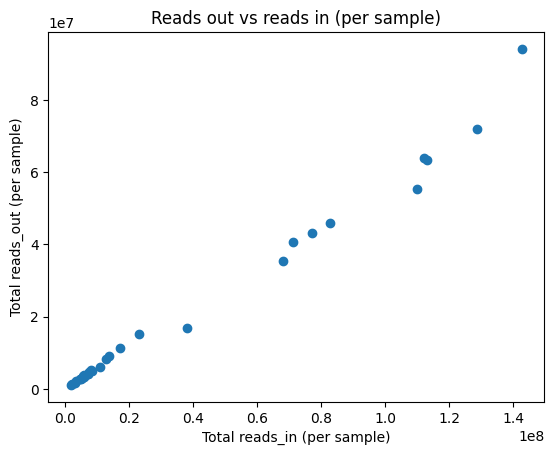

In [4]:
plt.figure()
plt.scatter(sample_summary["reads_in"], sample_summary["reads_out"])
plt.xlabel("Total reads_in (per sample)")
plt.ylabel("Total reads_out (per sample)")
plt.title("Reads out vs reads in (per sample)")
plt.show()


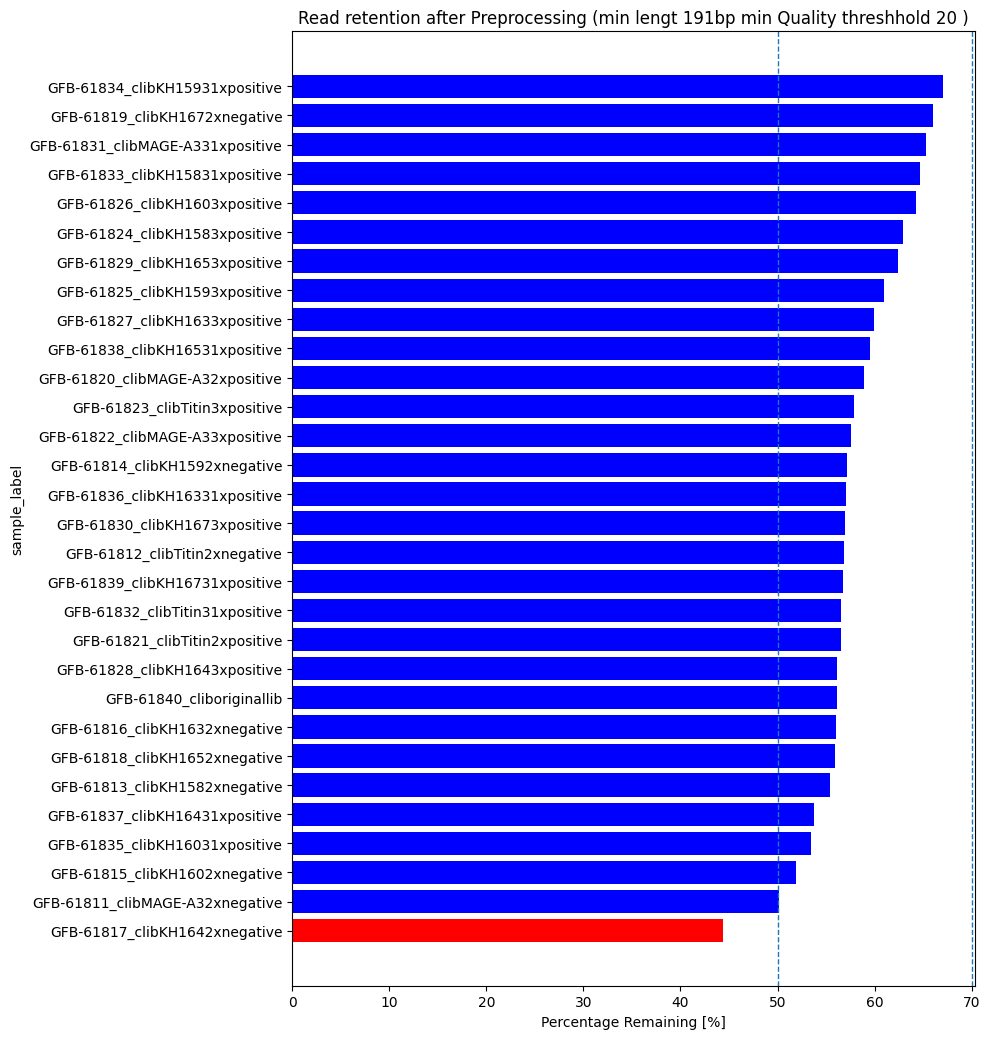

In [5]:
all_samples = sample_summary.sort_values("retention_reads_pct")

colors = [
    "red" if x < 50 else
    "blue" if x < 70 else
    "gray"
    for x in all_samples["retention_reads_pct"]
]

plt.figure(figsize=(10, max(4, 0.35 * len(all_samples))))
plt.barh(all_samples["sample_label"].astype(str),
         all_samples["retention_reads_pct"],
         color=colors)

plt.axvline(50, linestyle="--", linewidth=1)
plt.axvline(70, linestyle="--", linewidth=1)

plt.xlabel("Percentage Remaining [%]")
plt.ylabel("sample_label")
plt.title("Read retention after Preprocessing (min lengt 191bp min Quality threshhold 20 )")
plt.tight_layout()
plt.show()


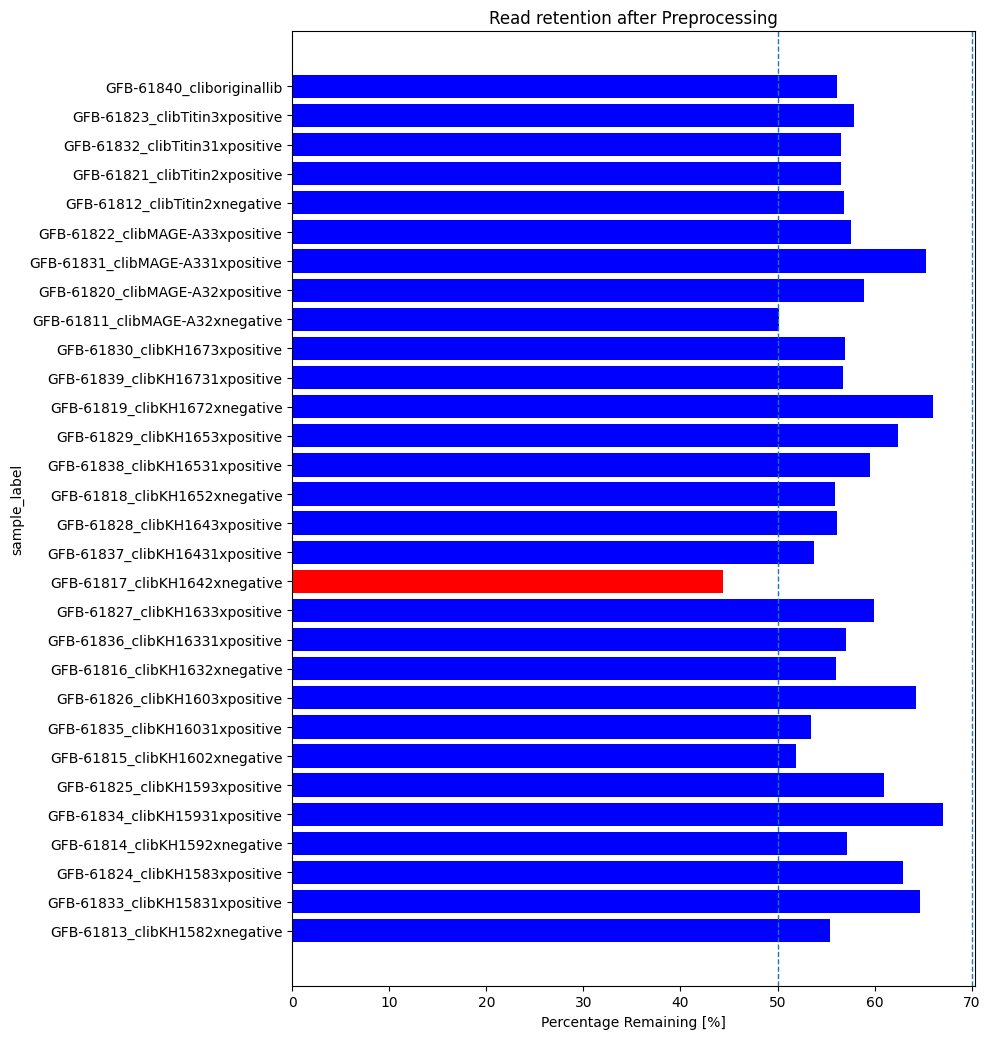

In [6]:
all_samples = sample_summary.sort_values(["sample_name"])

colors = [
    "red" if x < 50 else
    "blue" if x < 70 else
    "gray"
    for x in all_samples["retention_reads_pct"]
]

plt.figure(figsize=(10, max(4, 0.35 * len(all_samples))))
plt.barh(all_samples["sample_label"].astype(str),
         all_samples["retention_reads_pct"],
         color=colors)

plt.axvline(50, linestyle="--", linewidth=1)
plt.axvline(70, linestyle="--", linewidth=1)

plt.xlabel("Percentage Remaining [%]")
plt.ylabel("sample_label")
plt.title("Read retention after Preprocessing")
plt.tight_layout()
plt.show()
